# Processing human results

In [2]:
import pandas as pd

In [ ]:
data = pd.read_csv('CreativityEval_2026_05_04_10_38.csv')
expert_data = pd.read_csv('CreativityEval – Experts_18 May 2026_01.50.csv')
automated_metrics = pd.read_csv('automatic_metric_results/eval_results_human_eval_set.csv')
df_llm = pd.read_csv("../llm_judge_results/llm_judge_results_concat.csv")

## Reworking qualtrics format to useable format

In [63]:
from collections import defaultdict
import json
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Criteria mapping
criteria_mapping = {
	0 : 'grammaticaliteit',
	1 : 'coherentie',
	2 : 'orginaliteit',
	3 : 'creativiteit',
	4 : 'complexiteit',
	5 : 'plezier',
	6 : 'menselijkheid'
}

In [64]:
def reformat_qualtrics_data(data, skip_rows=2, n_stories=210):
	judge_reliability = []
	scores = np.zeros((n_stories, 7, 4)) # (stories, criteria, judges)
	story_mapping = {}

	for r, row in data[skip_rows:].iterrows(): # per participant
		mistake_counter = 0
		selected_stories = json.loads(row['selected_stories'])

		for i, info in enumerate(selected_stories): # per story
			likertQ_id = i + 1
			id = info['id']
			if id not in story_mapping.keys():
				story_mapping[id] = info['source']

			try:
				mistake_counter += int(row[f'incorrect_attempts_{likertQ_id}'])
			except:
				pass

			for criterium in criteria_mapping.keys(): # per criteria
				try:
					likertQ_value = int(row[f'{likertQ_id}_Likert_{criterium + 1}']) # likert scale starts from 1
				except:
					likertQ_value = 0.0
				no_judges = np.where(scores[id, criterium] == 0)[0][0]
				scores[id, criterium, no_judges] = likertQ_value
		judge_reliability.append(mistake_counter)

	return scores, story_mapping, judge_reliability

In [65]:
def reformat_qualtrics_to_long(data, skip_rows=2):
	judge_reliability = []

	scores = {'id' : [],
		   'source': [],
		   'judge': [],
		   'grammaticaliteit': [],
		   'coherentie': [],
		   'orginaliteit': [],
		   'creativiteit': [],
		   'complexiteit': [],
		   'plezier': [],
		   'menselijkheid': []}
	
	story_mapping = {}

	for r, row in data[skip_rows:].iterrows(): # per participant
		mistake_counter = 0
		selected_stories = json.loads(row['selected_stories'])

		for i, info in enumerate(selected_stories): # per story
			scores['judge'].append(r)
			likertQ_id = i + 1
			id = info['id']
			scores['id'].append(id)

			if id not in story_mapping.keys():
				story_mapping[id] = info['source']
			scores['source'].append(info['source'])

			try:
				mistake_counter += int(row[f'incorrect_attempts_{likertQ_id}'])
			except:
				pass
			
			for id_criterium, criterium in criteria_mapping.items(): # per criteria
				try:
					likertQ_value = int(row[f'{likertQ_id}_Likert_{id_criterium + 1}'])
				except:
					likertQ_value = np.nan
				scores[criterium].append(likertQ_value)

				
		judge_reliability.append(mistake_counter)
	
	df = pd.DataFrame(scores)
	return df, story_mapping, judge_reliability

### Numpy representation noob data

In [ ]:
# You did not re-index after selecting so you have indices up to 210 instead of 200
# Some rows are suppose to stay empty --> ids: 30, 53, 78, 82, 102, 105, 107, 142, 144, 161
scores_noobs, story_mapping_noobs, judge_reliability_noobs = reformat_qualtrics_data(data)

### Long format for mixed effect models (public data)

In [ ]:
df_long_noobs, _, _ = reformat_qualtrics_to_long(data)

df_for_mem = df_long_noobs.merge(automated_metrics.drop(columns=["source"], errors="ignore"), on="id")
df_for_mem["source"] = df_for_mem["source"].astype("category")

df_for_mem = df_for_mem.drop(['Unnamed: 0', 'story', 'question', 'answer_a', 'answer_b', 'answer_c', 'gold_label', 'story_length', 'lexical_diversity'], axis=1)
df_for_mem.to_csv('noob_eval_plus_automated.csv')

### Numpy representation of expert data

In [18]:
scores_experts, story_mapping_experts, judge_reliability_experts = reformat_qualtrics_data(expert_data, skip_rows=3)

## Interrater reliability

In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations
from pingouin import intraclass_corr
from sklearn.metrics import cohen_kappa_score
import krippendorff


def compute_category_krippendorff(
	scores_matrix: np.ndarray,
	n_bootstrap: int = 1000,
	ci: float = 0.95,
	seed: int = 42,
) -> dict:
	"""
	Compute Krippendorff's Alpha with bootstrapped confidence interval.

	Parameters
	----------
	scores_matrix : np.ndarray
		Shape (n_stories, n_judges). Zeros treated as missing (replaced with NaN).
	n_bootstrap : int
		Number of bootstrap resamples (default 1000).
	ci : float
		Confidence level, e.g. 0.95 for a 95% CI.
	seed : int
		Random seed for reproducibility.

	Returns
	-------
	dict with keys:
		"alpha"  : float  – point estimate
		"ci_low" : float  – lower bound of the bootstrapped CI
		"ci_high": float  – upper bound of the bootstrapped CI
	"""
	matrix = scores_matrix.astype(float).copy()
	matrix[matrix == 0] = np.nan

	# Krippendorff expects shape (n_judges, n_stories)
	matrix = matrix.T

	nan_result = {"alpha": np.nan, "ci_low": np.nan, "ci_high": np.nan}

	try:
		point_estimate = krippendorff.alpha(
			reliability_data=matrix,
			level_of_measurement="ordinal"
		)
	except Exception as e:
		print(f"Krippendorff's alpha failed: {e}")
		return nan_result

	# Bootstrap over stories (columns in judge×story matrix)
	rng = np.random.default_rng(seed)
	n_stories = matrix.shape[1]
	boot_alphas = []

	for _ in range(n_bootstrap):
		sample_idx = rng.integers(0, n_stories, size=n_stories)
		boot_matrix = matrix[:, sample_idx]
		try:
			a = krippendorff.alpha(
				reliability_data=boot_matrix,
				level_of_measurement="ordinal"
			)
			boot_alphas.append(a)
		except Exception:
			pass

	if len(boot_alphas) < n_bootstrap * 0.5:
		print("Warning: fewer than 50% of bootstrap resamples succeeded; CI may be unreliable.")

	tail = (1 - ci) / 2
	ci_low  = float(np.nanpercentile(boot_alphas, tail * 100))
	ci_high = float(np.nanpercentile(boot_alphas, (1 - tail) * 100))

	return {"alpha": point_estimate, "ci_low": ci_low, "ci_high": ci_high}


def compute_category_icc(scores_matrix: np.ndarray) -> float:
	"""
	Compute ICC(C,1) for one category across all stories.
	scores_matrix: shape (n_stories, n_judges), zeros treated as missing.
	"""
	n_stories, n_judges = scores_matrix.shape
	rows, cols, vals = [], [], []

	for story_idx in range(n_stories):
		scores = scores_matrix[story_idx]
		if np.any(scores == 0):
			continue
		for judge_idx in range(n_judges):
			rows.append(story_idx)
			cols.append(judge_idx)
			vals.append(scores[judge_idx])

	df_long = pd.DataFrame({
		"targets": rows,
		"raters": cols,
		"ratings": vals
	})

	if df_long["raters"].nunique() < 2 or df_long["targets"].nunique() < 2:
		return np.nan

	icc_result = intraclass_corr(
		data=df_long,
		targets="targets",
		raters="raters",
		ratings="ratings",
		nan_policy="omit"
	)
	return icc_result.loc[icc_result["Type"] == "ICC(C,1)", "ICC"].values[0]


def compute_category_weighted_kappa(
	scores_matrix: np.ndarray,
	weights: str = "quadratic"
) -> float:
	"""
	Compute mean pairwise weighted Cohen's Kappa for one category across all stories.
	scores_matrix: shape (n_stories, n_judges), zeros treated as missing.
	"""
	n_stories, n_judges = scores_matrix.shape
	matrix = scores_matrix.astype(float).copy()
	matrix[matrix == 0] = np.nan

	kappas = []
	for j1, j2 in combinations(range(n_judges), 2):
		col1 = matrix[:, j1]
		col2 = matrix[:, j2]

		both_valid = ~np.isnan(col1) & ~np.isnan(col2)
		r1 = col1[both_valid].astype(int)
		r2 = col2[both_valid].astype(int)

		if len(r1) < 2 or len(np.unique(np.concatenate([r1, r2]))) < 2:
			continue

		try:
			k = cohen_kappa_score(r1, r2, weights=weights)
			kappas.append(k)
		except Exception as e:
			print(f"Weighted kappa failed for judges ({j1}, {j2}): {e}")

	return float(np.mean(kappas)) if kappas else np.nan


def _irr_for_indices(
	results: np.ndarray,
	story_indices: list[int],
	criteria_names: list[str],
	kappa_weights: str,
	n_bootstrap: int,
	ci: float,
	bootstrap_seed: int,
) -> dict[str, dict]:
	"""
	Compute ICC, Krippendorff alpha (with CI), and weighted kappa for each
	criterion, restricted to the given story indices.

	Returns a nested dict:  { cname: { "icc", "alpha", "ci_low", "ci_high", "kappa" } }
	"""
	subset = results[story_indices]  # shape (n_subset, n_criteria, n_judges)
	out = {}
	for c, cname in enumerate(criteria_names):
		scores = subset[:, c, :]  # (n_subset, n_judges)
		out[cname] = {
			"icc":     compute_category_icc(scores),
			**compute_category_krippendorff(scores, n_bootstrap=n_bootstrap, ci=ci, seed=bootstrap_seed),
			"kappa":   compute_category_weighted_kappa(scores, weights=kappa_weights),
		}
	return out


def process_evaluation_results(
	results: np.ndarray,
	story_mapping: dict,
	story_ids: list,
	criteria_names: list[str] | None = None,
	kappa_weights: str = "quadratic",
	n_bootstrap: int = 1000,
	ci: float = 0.95,
	bootstrap_seed: int = 42,
) -> pd.DataFrame:
	"""
	Process human evaluation results into a summary DataFrame.

	IRR metrics (ICC, Krippendorff alpha + CI, weighted kappa) are computed:
	  - overall across all stories
	  - per source (one set of columns per unique source value)

	Each story row contains the overall IRR columns *and* the IRR columns for
	its own source, making it easy to filter or compare.

	Parameters
	----------
	results : np.ndarray
		Shape (n_stories, n_criteria, n_judges). Zero = missing judge.
	story_mapping : dict
		Maps story index (int) -> source string  (e.g. "sftw" or "chiscor").
	story_ids : list
		Story indices to include in the output.
	criteria_names : list[str], optional
		Names for each criterion. Defaults to ["crit_0", "crit_1", ...].
	kappa_weights : str
		Weighting scheme for Cohen's kappa: "quadratic" (default) or "linear".
	n_bootstrap : int
		Number of bootstrap resamples for Krippendorff's alpha CI (default 1000).
	ci : float
		Confidence level for the bootstrapped CI (default 0.95).
	bootstrap_seed : int
		Random seed for reproducibility (default 42).

	Returns
	-------
	pd.DataFrame
		One row per story.  IRR columns are prefixed:
		  {cname}_overall_{stat}
		  {cname}_{source}_{stat}
		where stat ∈ {icc, alpha, alpha_ci_low, alpha_ci_high, kappa}.
	"""
	n_stories, n_criteria, n_judges = results.shape

	if criteria_names is None:
		criteria_names = [f"crit_{i}" for i in range(n_criteria)]
	assert len(criteria_names) == n_criteria

	# ------------------------------------------------------------------ #
	# 1. IRR — overall                                                     #
	# ------------------------------------------------------------------ #
	overall_irr = _irr_for_indices(
		results, story_ids, criteria_names,
		kappa_weights, n_bootstrap, ci, bootstrap_seed,
	)

	# ------------------------------------------------------------------ #
	# 2. IRR — per source                                                  #
	# ------------------------------------------------------------------ #
	# Build source -> list of story indices
	source_to_ids: dict[str, list[int]] = {}
	for s in story_ids:
		src = story_mapping[s]
		source_to_ids.setdefault(src, []).append(s)

	source_irr: dict[str, dict] = {}
	for src, ids in source_to_ids.items():
		source_irr[src] = _irr_for_indices(
			results, ids, criteria_names,
			kappa_weights, n_bootstrap, ci, bootstrap_seed,
		)

	all_sources = sorted(source_to_ids.keys())

	# ------------------------------------------------------------------ #
	# 3. Per-story statistics                                              #
	# ------------------------------------------------------------------ #
	records = []

	for s in story_ids:
		src = story_mapping[s]
		row = {"id": s, "source": src}

		for c, cname in enumerate(criteria_names):
			scores = results[s, c, :]
			valid  = scores[scores != 0]
			n_valid = len(valid)

			row[f"{cname}_n_judges"]  = n_valid
			row[f"{cname}_mean"]      = np.mean(valid)        if n_valid > 0 else np.nan
			row[f"{cname}_median"]    = np.median(valid)      if n_valid > 0 else np.nan
			row[f"{cname}_std"]       = np.std(valid, ddof=1) if n_valid > 1 else np.nan
			row[f"{cname}_pct_agree"] = np.mean(valid == valid[0]) if n_valid > 0 else np.nan

			# Overall IRR
			row[f"{cname}_overall_icc"]           = overall_irr[cname]["icc"]
			row[f"{cname}_overall_alpha"]         = overall_irr[cname]["alpha"]
			row[f"{cname}_overall_alpha_ci_low"]  = overall_irr[cname]["ci_low"]
			row[f"{cname}_overall_alpha_ci_high"] = overall_irr[cname]["ci_high"]
			row[f"{cname}_overall_kappa"]         = overall_irr[cname]["kappa"]

			# Per-source IRR (columns for every source, filled for all rows)
			for source in all_sources:
				row[f"{cname}_{source}_icc"]           = source_irr[source][cname]["icc"]
				row[f"{cname}_{source}_alpha"]         = source_irr[source][cname]["alpha"]
				row[f"{cname}_{source}_alpha_ci_low"]  = source_irr[source][cname]["ci_low"]
				row[f"{cname}_{source}_alpha_ci_high"] = source_irr[source][cname]["ci_high"]
				row[f"{cname}_{source}_kappa"]         = source_irr[source][cname]["kappa"]

		records.append(row)

	df_stories = pd.DataFrame(records)

	# ------------------------------------------------------------------ #
	# 4. Column ordering                                                   #
	# ------------------------------------------------------------------ #
	meta_cols    = ["id", "source"]
	story_stats  = ["n_judges", "mean", "median", "std", "pct_agree"]
	irr_stats    = ["icc", "alpha", "alpha_ci_low", "alpha_ci_high", "kappa"]
	irr_prefixes = ["overall"] + all_sources

	ordered_cols = meta_cols + [
		f"{cname}_{stat}"
		for cname in criteria_names
		for stat in (
			story_stats
			+ [f"{prefix}_{irr}" for prefix in irr_prefixes for irr in irr_stats]
		)
	]

	df_stories = df_stories[ordered_cols]

	return df_stories

In [19]:
processed_results_noobs = process_evaluation_results(scores_noobs, story_mapping_noobs, [n for n in range(scores_noobs.shape[0]) if n not in [30, 53, 78, 82, 102, 105, 107, 142, 144, 161]], criteria_mapping.values())
processed_results_experts = process_evaluation_results(scores_experts, story_mapping_experts, list(story_mapping_experts.keys()), criteria_mapping.values())

### Interrater noobs

In [ ]:
# Counting on Consensus: Selecting the Right Inter-annotator Agreement Metric for NLP Annotation and Evaluation (IAA in NLP)
# A Guideline of Selecting and Reporting Intraclass Correlation Coefficients for Reliability Research (ICC in medical research)
# A Comparison of Reliability Coefficients for Ordinal Rating Scales
print('Noob agreement overall')

for idx, c in criteria_mapping.items():
	print(f'{c} : K alpha  {processed_results_noobs[f"{c}_overall_alpha"].iloc[0]}, alpha CI low {processed_results_noobs[f"{c}_overall_alpha_ci_low"].iloc[0]}, alpha CI high  {processed_results_noobs[f"{c}_overall_alpha_ci_high"].iloc[0]}')

Noob agreement overall
grammaticaliteit : K alpha  0.17278706269524635, alpha CI low 0.084878116533832, alpha CI high  0.2597413180652205
coherentie : K alpha  0.24463715943325814, alpha CI low 0.15467682298074376, alpha CI high  0.330376999090009
orginaliteit : K alpha  0.2128213618930852, alpha CI low 0.11845536019133157, alpha CI high  0.3073934875243001
creativiteit : K alpha  0.2603883932546941, alpha CI low 0.16867266352798657, alpha CI high  0.35224030389177097
complexiteit : K alpha  0.26424920478022706, alpha CI low 0.17028007068526574, alpha CI high  0.3513434948162394
plezier : K alpha  0.13963269318032134, alpha CI low 0.05172891693605771, alpha CI high  0.2330497258648873
menselijkheid : K alpha  0.14179114783679414, alpha CI low 0.04528743636283854, alpha CI high  0.23246258285664112


In [ ]:
print('Noob agreement chiscor')

for idx, c in criteria_mapping.items():
	print(f'{c} : K alpha  {processed_results_noobs[f"{c}_chiscor_alpha"].iloc[0]}, alpha CI low {processed_results_noobs[f"{c}_chiscor_alpha_ci_low"].iloc[0]}, alpha CI high  {processed_results_noobs[f"{c}_chiscor_alpha_ci_high"].iloc[0]}')

Noob agreement chiscor
grammaticaliteit : K alpha  0.21520593138032484, alpha CI low 0.07783321137041549, alpha CI high  0.3555162540980468
coherentie : K alpha  0.29539862791185156, alpha CI low 0.16345914520948196, alpha CI high  0.4226030553103513
orginaliteit : K alpha  0.32181882133792994, alpha CI low 0.19542217219579094, alpha CI high  0.43860608854739164
creativiteit : K alpha  0.40552549859106646, alpha CI low 0.2876005735795838, alpha CI high  0.5131871019166538
complexiteit : K alpha  0.34595299606019814, alpha CI low 0.22622657895223822, alpha CI high  0.46015430675635016
plezier : K alpha  0.17452513520004487, alpha CI low 0.04095233317854898, alpha CI high  0.3073865528815145
menselijkheid : K alpha  0.054459425454985944, alpha CI low -0.06063911646731794, alpha CI high  0.17564609663528147


In [ ]:
print('Noob agreement sftw')

for idx, c in criteria_mapping.items():
	print(f'{c} : K alpha  {processed_results_noobs[f"{c}_sftw_alpha"].iloc[0]}, alpha CI low {processed_results_noobs[f"{c}_sftw_alpha_ci_low"].iloc[0]}, alpha CI high  {processed_results_noobs[f"{c}_sftw_alpha_ci_high"].iloc[0]}')

Noob agreement sftw
grammaticaliteit : K alpha  0.12266246424296134, alpha CI low -0.0029397942288709594, alpha CI high  0.23719708521465796
coherentie : K alpha  0.18605222953585943, alpha CI low 0.049566924553825234, alpha CI high  0.30777686762938217
orginaliteit : K alpha  0.05051854367532116, alpha CI low -0.0802595437606122, alpha CI high  0.18355605670018812
creativiteit : K alpha  0.04500314446409481, alpha CI low -0.06998567641195819, alpha CI high  0.15992737407826674
complexiteit : K alpha  0.08680452509180747, alpha CI low -0.029274115211705785, alpha CI high  0.19596207612479122
plezier : K alpha  0.09532213996554317, alpha CI low -0.029322479989240483, alpha CI high  0.21749316317840914
menselijkheid : K alpha  0.02051049247868908, alpha CI low -0.1038802913046556, alpha CI high  0.13223365758220906


### Interrater experts

In [ ]:
print('Expert agreement overall')
for idx, c in criteria_mapping.items():
	print(f'{c} : K alpha  {processed_results_experts[f"{c}_overall_alpha"].iloc[0]}, alpha CI low {processed_results_experts[f"{c}_overall_alpha_ci_low"].iloc[0]}, alpha CI high  {processed_results_experts[f"{c}_overall_alpha_ci_high"].iloc[0]}')

Expert agreement overall
grammaticaliteit : K alpha  0.4885581281940278, alpha CI low 0.2469285795602841, alpha CI high  0.6586497678100272
coherentie : K alpha  0.44156816390858944, alpha CI low 0.168906344932599, alpha CI high  0.6458492448412033
orginaliteit : K alpha  -0.0042074328556886975, alpha CI low -0.23391096213776827, alpha CI high  0.21102841968483743
creativiteit : K alpha  0.037406364809850046, alpha CI low -0.18567675546438855, alpha CI high  0.2477180122809723
complexiteit : K alpha  0.20787163101710504, alpha CI low -0.020477187968945973, alpha CI high  0.41051417507885357
plezier : K alpha  0.34762209347238315, alpha CI low 0.08482794500080547, alpha CI high  0.5491907388425491
menselijkheid : K alpha  0.05016235815680925, alpha CI low -0.11519270476808743, alpha CI high  0.22307930803379733


In [ ]:
print('Expert agreement chiscor')
for idx, c in criteria_mapping.items():
	print(f'{c} : K alpha  {processed_results_experts[f"{c}_chiscor_alpha"].iloc[0]}, alpha CI low {processed_results_experts[f"{c}_chiscor_alpha_ci_low"].iloc[0]}, alpha CI high  {processed_results_experts[f"{c}_chiscor_alpha_ci_high"].iloc[0]}')

Expert agreement chiscor
grammaticaliteit : K alpha  0.32316993694988183, alpha CI low -0.04943441463401066, alpha CI high  0.5539931228607299
coherentie : K alpha  0.48695910548127297, alpha CI low 0.050144944768790015, alpha CI high  0.7410684409751573
orginaliteit : K alpha  0.12583028676323138, alpha CI low -0.17825095718800546, alpha CI high  0.3759840131011029
creativiteit : K alpha  0.28108619059895157, alpha CI low -0.036643306669783667, alpha CI high  0.5283449073402431
complexiteit : K alpha  0.410302677532014, alpha CI low 0.11240514644200747, alpha CI high  0.5721380946098519
plezier : K alpha  0.475277582572031, alpha CI low 0.12625674357675049, alpha CI high  0.6615152089322872
menselijkheid : K alpha  -0.20757717910914542, alpha CI low -0.36066123394315563, alpha CI high  -0.0357593469535021


In [ ]:
print('Expert agreement sftw')
for idx, c in criteria_mapping.items():
	print(f'{c} : K alpha  {processed_results_experts[f"{c}_sftw_alpha"].iloc[0]}, alpha CI low {processed_results_experts[f"{c}_sftw_alpha_ci_low"].iloc[0]}, alpha CI high  {processed_results_experts[f"{c}_sftw_alpha_ci_high"].iloc[0]}')

Expert agreement sftw
grammaticaliteit : K alpha  0.585628207989288, alpha CI low 0.24527286999459108, alpha CI high  0.7572849819054209
coherentie : K alpha  0.40921548966241705, alpha CI low -0.005765371109366058, alpha CI high  0.6600794842374227
orginaliteit : K alpha  -0.14996974757375536, alpha CI low -0.37215047834848963, alpha CI high  0.11054575163398683
creativiteit : K alpha  -0.2427344163511258, alpha CI low -0.38890680924946314, alpha CI high  -0.04174538731753869
complexiteit : K alpha  -0.2761584633853542, alpha CI low -0.39194523579619256, alpha CI high  -0.13902797455088947
plezier : K alpha  0.11751307051010329, alpha CI low -0.19274617615492928, alpha CI high  0.36164900355980784
menselijkheid : K alpha  -0.3642571306939124, alpha CI low -0.42037485831889504, alpha CI high  -0.3091136578186185


### Interrater LLM

In [ ]:
import numpy as np
import pandas as pd
import krippendorff

def compute_krippendorff_from_long(
	df: pd.DataFrame,
	criteria: list[str],
	id_col: str = "id",
	judge_col: str = "judge",
	n_bootstrap: int = 1000,
	ci: float = 0.95,
	seed: int = 42,
) -> pd.DataFrame:
	"""
	Compute Krippendorff's alpha with bootstrapped CI for each criterion
	from a long-format LLM evaluation DataFrame.

	Parameters
	----------
	df : pd.DataFrame
		Long-format data. One row per (story, judge) combination.
		Must contain columns: id_col, judge_col, and all criteria columns.
	criteria : list[str]
		Criterion columns to evaluate.
	id_col : str
		Column identifying the story/item (default "id").
	judge_col : str
		Column identifying the judge/model (default "judge").
	n_bootstrap : int
		Number of bootstrap resamples (default 1000).
	ci : float
		Confidence level for the bootstrapped CI (default 0.95).
	seed : int
		Random seed for reproducibility.

	Returns
	-------
	pd.DataFrame
		One row per criterion with columns:
		criterion, n_items, n_judges, alpha, alpha_ci_low, alpha_ci_high.
	"""
	# Pivot to wide format: rows = items, columns = judges
	# Missing (item, judge) combinations become NaN
	records = []
	for criterion in criteria:
		wide = (
			df[[id_col, judge_col, criterion]]
			.pivot(index=id_col, columns=judge_col, values=criterion)
			.astype(float)
		)

		# Krippendorff expects shape (n_judges, n_items)
		matrix = wide.values.T

		n_items  = wide.shape[0]
		n_judges = wide.shape[1]

		# --- Point estimate ---
		try:
			alpha_point = krippendorff.alpha(
				reliability_data=matrix,
				level_of_measurement="ordinal",
			)
		except Exception as e:
			print(f"Krippendorff's alpha failed for '{criterion}': {e}")
			records.append({
				"criterion":    criterion,
				"n_items":      n_items,
				"n_judges":     n_judges,
				"alpha":        np.nan,
				"alpha_ci_low": np.nan,
				"alpha_ci_high": np.nan,
			})
			continue

		# --- Bootstrapped CI (resample items with replacement) ---
		rng = np.random.default_rng(seed)
		boot_alphas = []

		for _ in range(n_bootstrap):
			sample_idx  = rng.integers(0, n_items, size=n_items)
			boot_matrix = matrix[:, sample_idx]
			try:
				a = krippendorff.alpha(
					reliability_data=boot_matrix,
					level_of_measurement="ordinal",
				)
				boot_alphas.append(a)
			except Exception:
				pass

		if len(boot_alphas) < n_bootstrap * 0.5:
			print(f"Warning: fewer than 50% of bootstrap resamples succeeded for '{criterion}'; CI may be unreliable.")

		tail    = (1 - ci) / 2
		ci_low  = float(np.nanpercentile(boot_alphas, tail * 100))
		ci_high = float(np.nanpercentile(boot_alphas, (1 - tail) * 100))

		records.append({
			"criterion":     criterion,
			"n_items":       n_items,
			"n_judges":      n_judges,
			"alpha":         alpha_point,
			"alpha_ci_low":  ci_low,
			"alpha_ci_high": ci_high,
		})

	return pd.DataFrame(records, columns=[
		"criterion", "n_items", "n_judges",
		"alpha", "alpha_ci_low", "alpha_ci_high",
	])


def compute_krippendorff_by_source(
	df: pd.DataFrame,
	story_mapping: dict,
	sources: list[str] | None = None,
	criteria: list[str] | None = None,
	id_col: str = "id",
	judge_col: str = "judge",
	n_bootstrap: int = 1000,
	ci: float = 0.95,
	seed: int = 42,
) -> pd.DataFrame:
	"""
	Compute Krippendorff's alpha per source per criterion from a long-format
	LLM evaluation DataFrame, using story_mapping to assign sources.

	Parameters
	----------
	df : pd.DataFrame
		Long-format data. One row per (story, judge) combination.
	story_mapping : dict
		Maps story id -> source string (e.g. "chiscor" or "sftw").
	sources : list[str], optional
		Which sources to include. Defaults to all unique sources in story_mapping.
	criteria : list[str]
		Criterion columns to evaluate.
	id_col : str
		Column identifying the story/item (default "id").
	judge_col : str
		Column identifying the judge/model (default "judge").
	n_bootstrap : int
		Number of bootstrap resamples (default 1000).
	ci : float
		Confidence level for the bootstrapped CI (default 0.95).
	seed : int
		Random seed for reproducibility.

	Returns
	-------
	pd.DataFrame
		One row per (source, criterion) with columns:
		source, criterion, n_items, n_judges, alpha, alpha_ci_low, alpha_ci_high.
	"""
	df = df.copy()
	df["source"] = df[id_col].map(story_mapping)

	if sources is None:
		sources = sorted(df["source"].dropna().unique())

	results = pd.concat([
		compute_krippendorff_from_long(
			df[df["source"] == source],
			criteria=criteria,
			id_col=id_col,
			judge_col=judge_col,
			n_bootstrap=n_bootstrap,
			ci=ci,
			seed=seed,
		).assign(source=source)
		for source in sources
	], ignore_index=True)

	return results[[
		"source", "criterion", "n_items", "n_judges",
		"alpha", "alpha_ci_low", "alpha_ci_high",
	]]


In [ ]:
results_by_source = compute_krippendorff_by_source(
	df_llm, 
	story_mapping_noobs,
	criteria=criteria_mapping.values(),
	sources=["chiscor", "sftw"],  # omit to include all sources
)
results_by_source

,source,criterion,n_items,n_judges,alpha,alpha_ci_low,alpha_ci_high
0,chiscor,grammaticaliteit,100,4,0.318000,0.211195,0.405609
1,chiscor,coherentie,100,4,0.393794,0.287290,0.483995
2,chiscor,orginaliteit,100,4,0.280691,0.174211,0.371243
3,chiscor,creativiteit,100,4,0.627898,0.536622,0.695338
4,chiscor,complexiteit,100,4,0.366020,0.255319,0.458738
5,chiscor,plezier,100,4,0.532439,0.430197,0.612996
6,chiscor,menselijkheid,100,4,0.035682,-0.043596,0.108530
7,sftw,grammaticaliteit,100,4,0.129258,0.035444,0.222633
8,sftw,coherentie,100,4,0.284001,0.172145,0.382490
9,sftw,orginaliteit,100,4,-0.101607,-0.164099,-0.034067


## Correlation with metrics (human)

In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# Define the metric -> human criterion mapping
METRIC_TO_CRITERION = {
	"creative_perplexity_dep": ["creativiteit", "orginaliteit", "plezier"],  # one metric, two criteria
	"local_contextuality":     ["coherentie"],
	"grammaticality":          ["grammaticaliteit"],
	"self-bleu":               ["coherentie"],
	"lexical_diversity":       ["complexiteit"],
	"unique-words":            ["complexiteit"],
	"avg-word-length":         ["complexiteit"],
	"average_components":      ["complexiteit"],
	"dependency_distance":     ["complexiteit"],
	"syntactic_depth":         ["complexiteit"],
	"surprise":				   ["creativiteit", "orginaliteit", "plezier"]
}


def compute_metric_correlations(
	df_summary: pd.DataFrame,
	df_auto: pd.DataFrame,
	story_mapping: dict,
	metric_to_criterion: dict,
	human_score_type: str = "mean",
	apply_fdr: bool = True,
) -> pd.DataFrame:
	"""
	Spearman correlations between automatic metrics and judge summary scores.
	Reports correlations overall and split by source.
	Reusable for both human and LLM judge summary dataframes.
	"""
	df = df_auto.merge(df_summary, on="id")
	df["source"] = df["id"].map(story_mapping)

	subsets = {"overall": df, **{src: df[df["source"] == src] for src in df["source"].unique()}}

	records = []
	for subset_name, subset_df in subsets.items():
		for metric, criteria in metric_to_criterion.items():
			for criterion in criteria:
				human_col = f"{criterion}_{human_score_type}"

				if metric not in subset_df.columns:
					print(f"Warning: '{metric}' not found, skipping.")
					continue
				if human_col not in subset_df.columns:
					print(f"Warning: '{human_col}' not found, skipping.")
					continue

				valid = subset_df[[metric, human_col]].dropna()
				n = len(valid)
				if n < 3:
					print(f"Warning: too few observations for {metric} <-> {human_col} in '{subset_name}', skipping.")
					continue

				r, p = spearmanr(valid[metric], valid[human_col])
				records.append({
					"subset":     subset_name,
					"metric":     metric,
					"criterion":  criterion,
					"spearman_r": round(r, 4),
					"p_value":    round(p, 4),
					"n":          n,
				})

	corr_df = pd.DataFrame(records).sort_values(["subset", "criterion"])

	if apply_fdr and len(corr_df) > 0:
		# Apply FDR correction within each subset separately
		adjusted_p = np.ones(len(corr_df))
		for subset_name in corr_df["subset"].unique():
			mask = corr_df["subset"] == subset_name
			adjusted_p[mask] = multipletests(corr_df.loc[mask, "p_value"], method="fdr_bh")[1]
		corr_df["p_adjusted"]           = adjusted_p.round(4)
		corr_df["significant_adjusted"] = corr_df["p_adjusted"] < 0.05
	else:
		corr_df["significant"] = corr_df["p_value"] < 0.05

	return corr_df

### With noob ratings

In [37]:
corr_df = compute_metric_correlations(processed_results_noobs, automated_metrics, story_mapping_noobs, METRIC_TO_CRITERION, human_score_type="mean")
print(corr_df.to_string(index=False))

 subset                  metric        criterion  spearman_r  p_value   n  p_adjusted  significant_adjusted
chiscor     local_contextuality       coherentie     -0.1538   0.1265 100      0.1460                 False
chiscor               self-bleu       coherentie     -0.3016   0.0023 100      0.0086                  True
chiscor       lexical_diversity     complexiteit      0.4505   0.0000 100      0.0000                  True
chiscor            unique-words     complexiteit      0.7206   0.0000 100      0.0000                  True
chiscor         avg-word-length     complexiteit      0.2290   0.0219 100      0.0657                 False
chiscor      average_components     complexiteit      0.1218   0.2275 100      0.2438                 False
chiscor     dependency_distance     complexiteit      0.3564   0.0003 100      0.0015                  True
chiscor         syntactic_depth     complexiteit      0.2171   0.0300 100      0.0750                 False
chiscor creative_perplexity_

### With expert ratings

In [30]:
corr_df = compute_metric_correlations(processed_results_experts, automated_metrics, story_mapping_experts, METRIC_TO_CRITERION, human_score_type="mean")
print(corr_df.to_string(index=False))

 subset                  metric        criterion  spearman_r  p_value  n  p_adjusted  significant_adjusted
chiscor     local_contextuality       coherentie      0.0145   0.9590 15      0.9742                 False
chiscor               self-bleu       coherentie     -0.5232   0.0453 15      0.2265                 False
chiscor       lexical_diversity     complexiteit      0.6881   0.0046 15      0.0345                  True
chiscor            unique-words     complexiteit      0.8458   0.0001 15      0.0015                  True
chiscor         avg-word-length     complexiteit      0.4034   0.1360 15      0.4080                 False
chiscor      average_components     complexiteit      0.1332   0.6359 15      0.9742                 False
chiscor     dependency_distance     complexiteit      0.0329   0.9075 15      0.9742                 False
chiscor         syntactic_depth     complexiteit     -0.0091   0.9742 15      0.9742                 False
chiscor creative_perplexity_dep     c

## Correlation with LLM-as-a-judge

In [92]:
import pandas as pd
import numpy as np
from pingouin import intraclass_corr
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests

# ── 1. MEAN / MEDIAN / STD / ICC per story per category ──────────────────────
def compute_category_icc_from_long(df_long: pd.DataFrame, criterion: str) -> float:
	"""
	Compute ICC(A,1) for one criterion from a long-format dataframe.
	df_long must have columns: id, judge, <criterion>
	"""
	subset = df_long[["id", "judge", criterion]].dropna()

	if subset["judge"].nunique() < 2 or subset["id"].nunique() < 2:
		return np.nan

	icc_result = intraclass_corr(
		data=subset,
		targets="id",
		raters="judge",
		ratings=criterion,
		nan_policy="omit"
	)
	return icc_result.loc[icc_result["Type"] == "ICC(A,1)", "ICC"].values[0]


def process_llm_judge_results(
	df: pd.DataFrame,
	criteria: list[str],
) -> pd.DataFrame:
	"""
	Process LLM-as-a-judge results from long format into a summary DataFrame.

	Parameters
	----------
	df : pd.DataFrame
		Long-format dataframe with columns: id, judge, <criteria...>
	criteria : list[str]
		Criterion column names to process.

	Returns
	-------
	pd.DataFrame
		One row per story with per-criterion mean, median, std, pct_agree, n_judges, and ICC.
	"""
	# Per-category ICC across all stories
	category_icc = {
		criterion: compute_category_icc_from_long(df, criterion)
		for criterion in criteria
	}

	# Per-story aggregation
	records = []
	for story_id, group in df.groupby("id"):
		row = {"id": story_id}

		for criterion in criteria:
			valid = group[criterion].dropna()
			n_valid = len(valid)

			row[f"{criterion}_n_judges"]  = n_valid
			row[f"{criterion}_mean"]      = valid.mean()               if n_valid > 0 else np.nan
			row[f"{criterion}_median"]    = valid.median()             if n_valid > 0 else np.nan
			row[f"{criterion}_std"]       = valid.std(ddof=1)          if n_valid > 1 else np.nan
			row[f"{criterion}_pct_agree"] = (valid == valid.iloc[0]).mean() if n_valid > 0 else np.nan
			row[f"{criterion}_icc"]       = category_icc[criterion]  # same for all rows in category

		records.append(row)

	df_summary = pd.DataFrame(records)

	# Order columns
	stat_suffixes = ["n_judges", "mean", "median", "std", "pct_agree", "icc"]
	ordered_cols = ["id"] + [
		f"{criterion}_{stat}"
		for criterion in criteria
		for stat in stat_suffixes
	]
	return df_summary[ordered_cols]


# ── 3. CORRELATION BETWEEN LLM JUDGE AND HUMAN SCORES ────────────────────────
def compute_llm_vs_human_correlations(
	df_llm: pd.DataFrame,
	df_human: pd.DataFrame,
	criteria: list[str],
	score_type: str = "mean",
	apply_fdr: bool = True,
) -> pd.DataFrame:
	"""
	Spearman correlations between LLM judge and human evaluation scores per criterion.

	Parameters
	----------
	df_llm : pd.DataFrame
		Output of process_llm_judge_results().
	df_human : pd.DataFrame
		Output of process_evaluation_results() from human judges.
	criteria : list[str]
		Criteria to correlate. Only criteria present in both dataframes are used.
	score_type : str
		"mean" or "median".
	apply_fdr : bool
		Whether to apply Benjamini-Hochberg FDR correction.
	"""
	df = df_llm.merge(df_human, on="id", suffixes=("_llm", "_human"))

	records = []
	for criterion in criteria:
		llm_col   = f"{criterion}_{score_type}_llm"
		human_col = f"{criterion}_{score_type}_human"

		if llm_col not in df.columns or human_col not in df.columns:
			print(f"Warning: columns for '{criterion}' not found, skipping.")
			continue

		valid = df[[llm_col, human_col]].dropna()
		n = len(valid)
		if n < 3:
			print(f"Warning: too few observations for '{criterion}', skipping.")
			continue

		r, p = spearmanr(valid[llm_col], valid[human_col])
		records.append({
			"criterion":  criterion,
			"spearman_r": round(r, 4),
			"p_value":    round(p, 4),
			"n":          n,
		})

	corr_df = pd.DataFrame(records).sort_values("criterion")

	if apply_fdr and len(corr_df) > 0:
		corr_df["p_adjusted"]           = multipletests(corr_df["p_value"], method="fdr_bh")[1].round(4)
		corr_df["significant_adjusted"] = corr_df["p_adjusted"] < 0.05
	else:
		corr_df["significant"] = corr_df["p_value"] < 0.05

	return corr_df

In [93]:
# Load your LLM judge data
df_llm_raw = pd.read_csv("../llm_judge_results/llm_judge_results_concat.csv")
# columns: id, judge, grammaticality, coherence, originality, creativity, complexity, likeability, humanlikeness

# 1. Summarise LLM judge results (same structure as human df)
df_llm = process_llm_judge_results(df_llm_raw, criteria_mapping.values())

# 2. Correlate LLM judge scores with automated metrics
corr_llm_vs_auto = compute_metric_correlations(df_llm, automated_metrics, story_mapping_noobs, METRIC_TO_CRITERION)
print('Correlation llm vs auto\n')
print(corr_llm_vs_auto)
# 3. Correlate LLM judge scores with human scores
corr_llm_vs_human = compute_llm_vs_human_correlations(df_llm, processed_results_noobs, criteria_mapping.values())

print('Correlation llm vs human\n')
print(corr_llm_vs_human)

Correlation llm vs auto

     subset                   metric         criterion  spearman_r  p_value  \
33  chiscor      local_contextuality        coherentie     -0.0889   0.3789   
35  chiscor                self-bleu        coherentie     -0.1547   0.1243   
36  chiscor        lexical_diversity      complexiteit      0.5194   0.0000   
37  chiscor             unique-words      complexiteit      0.8258   0.0000   
38  chiscor          avg-word-length      complexiteit      0.0983   0.3308   
39  chiscor       average_components      complexiteit      0.3041   0.0021   
40  chiscor      dependency_distance      complexiteit      0.3273   0.0009   
41  chiscor          syntactic_depth      complexiteit      0.2297   0.0215   
30  chiscor  creative_perplexity_dep      creativiteit      0.2572   0.0098   
42  chiscor                 surprise      creativiteit      0.0838   0.4070   
34  chiscor           grammaticality  grammaticaliteit      0.3313   0.0008   
31  chiscor  creative_perpl

## Plots per category

In [98]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_grouped_bar_by_evaltype(
	df_public: pd.DataFrame,
	df_expert: pd.DataFrame,
	story_mapping: dict,
	criteria: list[str],
	score_type: str = "mean",
	criteria_labels: list[str] | None = None,
	sources: list[str] = ["chiscor", "sftw"],
	source_labels: list[str] | None = None,
	eval_labels: list[str] = ["LLM", "Expert"],
	figsize: tuple | None = None,
	colors: tuple[str, str] = ("tab:blue", "tab:orange"),
	output_dir: str = ".",
) -> None:
	if criteria_labels is None:
		criteria_labels = [c.capitalize() for c in criteria]
	if source_labels is None:
		source_labels = sources
	if figsize is None:
		figsize = (len(criteria) * 1.4 * 2, 4)  # wider to fit two subplots

	for df in [df_public, df_expert]:
		if "source" not in df.columns:
			df["source"] = df["id"].map(story_mapping)

	bar_width   = 0.35
	group_gap   = 0.1
	group_width = len(sources) * bar_width + group_gap
	x_centers   = np.arange(len(criteria)) * group_width

	fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

	for ax, ev_label, df in zip(axes, eval_labels, [df_public, df_expert]):
		for i, (src, src_label, color) in enumerate(zip(sources, source_labels, colors)):
			subset  = df[df["source"] == src]
			offsets = x_centers + (i - (len(sources) - 1) / 2) * bar_width

			means, ci_errs = [], []
			for crit in criteria:
				col  = f"{crit}_{score_type}"
				vals = subset[col].dropna().values if col in df.columns else np.array([])
				if len(vals) == 0:
					means.append(np.nan)
					ci_errs.append(np.nan)
				elif len(vals) == 1:
					means.append(vals[0])
					ci_errs.append(0.0)
				else:
					means.append(np.mean(vals))
					ci_errs.append(1.96 * np.std(vals, ddof=1) / np.sqrt(len(vals)))

			ax.bar(
				offsets, means,
				width=bar_width,
				color=color,
				alpha=0.40,
				edgecolor=color,
				linewidth=1.5,
				label=src_label,
				yerr=ci_errs,
				capsize=3,
				error_kw={"elinewidth": 1.5, "ecolor": color, "alpha": 0.7},
				zorder=3,
			)

		ax.set_xticks(x_centers)
		ax.set_xticklabels(criteria_labels, rotation=30, ha="right", fontsize=9)
		ax.set_title(f"Subjective evaluation — {ev_label}", fontsize=9, fontweight="bold")
		ax.spines[["top", "right"]].set_visible(False)
		ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
		ax.set_yticks(np.arange(0, 5.5, 0.5))
		ax.set_axisbelow(True)
		ax.legend(frameon=False, fontsize=9)

	axes[0].set_ylabel(f"{score_type.capitalize()} score", fontsize=10)

	plt.tight_layout()
	fname = f"human_eval_combined.pdf"
	plt.savefig(fname, dpi=300, bbox_inches="tight")
	print(f"Saved to {fname}")
	plt.show()

Saved to human_eval_combined.pdf


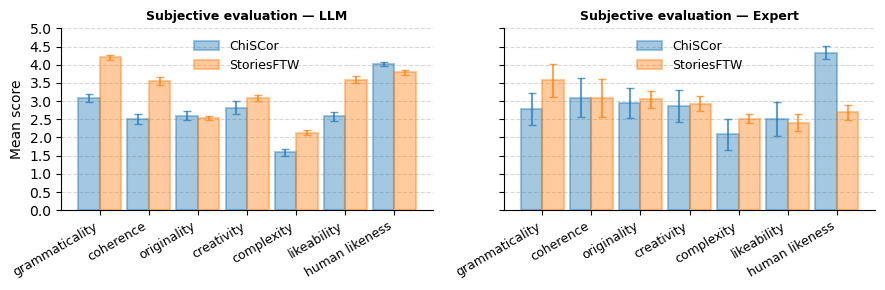

In [99]:
plot_grouped_bar_by_evaltype(
	df_public=df_llm,
	df_expert=processed_results_experts,
	story_mapping=story_mapping_noobs,
	criteria=list(criteria_mapping.values()),
	criteria_labels=['grammaticality', 'coherence', 'originality', 'creativity', 'complexity', 'likeability', 'human likeness'],
	source_labels=["ChiSCor", "StoriesFTW"],              # optional nicer labels
	output_dir="",
	figsize=(9, 3)
)

In [100]:
def plot_one_eval_method(
	df: pd.DataFrame,
	story_mapping: dict,
	criteria: list[str],
	criteria_labels: list[str] | None = None,
	sources: list[str] = ["chiscor", "sftw"],
	source_labels: list[str] | None = None,
	figsize: tuple | None = None,
	colors: tuple[str, str] = ("tab:blue", "tab:orange"),
	output_file: str = "plot.pdf",
) -> None:
	if criteria_labels is None:
		criteria_labels = [c.capitalize() for c in criteria]
	if source_labels is None:
		source_labels = sources
	if figsize is None:
		figsize = (len(criteria) * 1.4, 4)

	if "source" not in df.columns:
		df["source"] = df["id"].map(story_mapping)

	# Average over judges first, then over stories
	df_avg = df.groupby(["id", "source"])[criteria].mean().reset_index()

	bar_width   = 0.35
	group_gap   = 0.1
	group_width = len(sources) * bar_width + group_gap
	x_centers   = np.arange(len(criteria)) * group_width

	fig, ax = plt.subplots(figsize=figsize)

	for i, (src, src_label, color) in enumerate(zip(sources, source_labels, colors)):
		subset  = df_avg[df_avg["source"] == src]
		offsets = x_centers + (i - (len(sources) - 1) / 2) * bar_width

		means, ci_errs = [], []
		for crit in criteria:
			vals = subset[crit].dropna().values
			if len(vals) == 0:
				means.append(np.nan)
				ci_errs.append(np.nan)
			elif len(vals) == 1:
				means.append(vals[0])
				ci_errs.append(0.0)
			else:
				means.append(np.mean(vals))
				ci_errs.append(1.96 * np.std(vals, ddof=1) / np.sqrt(len(vals)))

		ax.bar(
			offsets, means,
			width=bar_width,
			color=color,
			alpha=0.40,
			edgecolor=color,
			linewidth=1.5,
			label=src_label,
			yerr=ci_errs,
			capsize=3,
			error_kw={"elinewidth": 1.5, "ecolor": color, "alpha": 0.7},
			zorder=3,
		)

	ax.set_xticks(x_centers)
	ax.set_xticklabels(criteria_labels, rotation=30, ha="right", fontsize=9)
	ax.set_ylabel("Mean score", fontsize=10)
	ax.set_title("Human evaluation – crowd", fontsize=11, fontweight="bold")
	ax.spines[["top", "right"]].set_visible(False)
	ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
	ax.set_yticks(np.arange(0, 5.5, 0.5))
	ax.set_axisbelow(True)
	ax.legend(frameon=False, fontsize=9)

	plt.tight_layout()
	plt.savefig(output_file, dpi=300, bbox_inches="tight")
	print(f"Saved to {output_file}")
	plt.show()

Saved to crowd_judgements.pdf


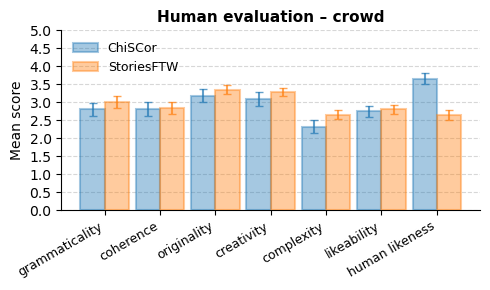

In [ ]:
plot_one_eval_method(
	df=df_long_noobs,
	story_mapping=story_mapping_noobs,
	criteria=list(criteria_mapping.values()),
	criteria_labels=['grammaticality', 'coherence', 'originality', 'creativity', 'complexity', 'likeability', 'human likeness'],
	source_labels=["ChiSCor", "StoriesFTW"],              # optional nicer labels
	output_file="crowd_judgements.pdf",
	figsize=(5, 3)
)

In [ ]:
from scipy import stats
from statsmodels.stats.multitest import multipletests

def test_source_differences(
	df: pd.DataFrame,
	story_mapping: dict,
	criteria: list[str],
	score_type: str = "mean",
	eval_label: str = "Evaluation",
	correction: str = "fdr_bh",  # or "bonferroni"
) -> pd.DataFrame:
	"""
	For each criterion, runs a Mann-Whitney U test comparing scores
	between 'chiscor' (real) and 'sftw' (generated) stories.
	Applies multiple-comparison correction across criteria.

	Returns a DataFrame with test statistics and significance flags.
	"""
	if "source" not in df.columns:
		df["source"] = df["id"].map(story_mapping)

	rows = []
	for crit in criteria:
		col = f"{crit}_{score_type}"
		if col not in df.columns:
			continue

		real = df[df["source"] == "chiscor"][col].dropna().values
		gen  = df[df["source"] == "sftw"][col].dropna().values

		if len(real) < 2 or len(gen) < 2:
			continue

		stat, p = stats.mannwhitneyu(real, gen, alternative="two-sided")

		# Effect size: rank-biserial correlation r = 1 - 2U/(n1*n2)
		r = 1 - (2 * stat) / (len(real) * len(gen))

		rows.append({
			"criterion":  crit,
			"n_real":     len(real),
			"n_gen":      len(gen),
			"mean_real":  np.mean(real),
			"mean_gen":   np.mean(gen),
			"U_stat":     stat,
			"p_raw":      p,
			"effect_r":   r,
		})

	results = pd.DataFrame(rows)

	# Multiple comparison correction
	reject, p_corrected, _, _ = multipletests(results["p_raw"], method=correction)
	results["p_corrected"] = p_corrected
	results["significant"] = reject

	print(f"\n=== {eval_label} — Mann-Whitney U (correction: {correction}) ===")
	print(results.to_string(index=False, float_format="{:.3f}".format))
	return results

In [ ]:
results_public = test_source_differences(
	processed_results_noobs, story_mapping_noobs, criteria_mapping.values(),
	score_type="mean", eval_label="Public"
)

results_expert = test_source_differences(
	processed_results_experts, story_mapping_experts, criteria_mapping.values(),
	score_type="mean", eval_label="Expert"
)


=== Public — Mann-Whitney U (correction: fdr_bh) ===
       criterion  n_real  n_gen  mean_real  mean_gen   U_stat  p_raw  effect_r  p_corrected  significant
grammaticaliteit     100    100      2.792     2.967 4387.000  0.132     0.123        0.309        False
      coherentie     100    100      2.828     2.862 4920.000  0.845     0.016        0.864        False
    orginaliteit     100    100      3.200     3.312 4821.000  0.661     0.036        0.864        False
    creativiteit     100    100      3.105     3.270 4629.500  0.363     0.074        0.635        False
    complexiteit     100    100      2.297     2.675 3624.000  0.001     0.275        0.003         True
         plezier     100    100      2.758     2.735 5069.500  0.864    -0.014        0.864        False
   menselijkheid     100    100      3.680     2.572 8230.000  0.000    -0.646        0.000         True

=== Expert — Mann-Whitney U (correction: fdr_bh) ===
       criterion  n_real  n_gen  mean_real  mean_gen

In [ ]:
results_public = test_source_differences(
	processed_results_noobs, story_mapping_noobs, criteria_mapping.values(),
	score_type="mean", eval_label="Public"
)

results_expert = test_source_differences(
	processed_results_experts, story_mapping_experts, criteria_mapping.values(),
	score_type="mean", eval_label="Expert"
)


=== Public — Mann-Whitney U (correction: fdr_bh) ===
       criterion  n_real  n_gen  mean_real  mean_gen   U_stat  p_raw  effect_r  p_corrected  significant
grammaticaliteit     100    100      2.800     3.010 4240.500  0.062     0.152        0.145        False
      coherentie     100    100      2.822     2.841 4946.000  0.896     0.011        0.896        False
    orginaliteit     100    100      3.186     3.348 4584.500  0.308     0.083        0.433        False
    creativiteit     100    100      3.098     3.287 4586.000  0.309     0.083        0.433        False
    complexiteit     100    100      2.324     2.660 3715.000  0.002     0.257        0.006         True
         plezier     100    100      2.745     2.805 4762.000  0.558     0.048        0.651        False
   menselijkheid     100    100      3.657     2.647 8205.500  0.000    -0.641        0.000         True

=== Expert — Mann-Whitney U (correction: fdr_bh) ===
       criterion  n_real  n_gen  mean_real  mean_gen